# Experiments with exploding activations

In [1]:
from functools import partial
import math

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [2]:
# prevents numerical underflow issues for very small gain factor
# double precision also makes training curves nearly identical in last plot
torch.set_default_dtype(torch.float64)

First we load the MNIST dataset.

In [3]:
def load_data():
    train_ds = MNIST('data', train=True, transform=ToTensor(), download=True)
    val_ds = MNIST('data', train=False, transform=ToTensor(), download=True)
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=1000, shuffle=False)
    return train_dl, val_dl

Second, we create a 5-layer ReLU MLP. We set the bias to `false` to prevent exploding gradients. We also write a custom initialization function.

In [4]:
num_layers = 5

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential()
        for i in range(num_layers-1):
            self.layers.add_module(f"Dense {i+1}", nn.LazyLinear(64, bias=False))
            self.layers.add_module(f"Activation {i+1}", nn.ReLU())
        self.layers.add_module(f"Dense {num_layers})", nn.LazyLinear(10, bias=False))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)

In [6]:
def custom_init(gain, m):
    if isinstance(m, nn.Linear):
        std = gain * math.sqrt(2 / m.weight.shape[1]) # He init
        nn.init.normal_(m.weight, std=std)
        if m.bias is not None:
            raise NameError("Bias should not exist")

def apply_init(model, gain):
    model(torch.zeros(1, 784)) # initialize lazy layers
    init_fn = partial(custom_init, gain)
    model.apply(init_fn)

## First experiment: no output activation scaling

In [7]:
default_lr = 0.05

We consider five different values for the gain factor. We set a different learning rate for each value of the gain factor, to ensure that $||\Delta W|| / ||W||$ doesn't depend on the gain factor. For each gain factor, we also set a variable `logit_scalings` to 1. This scales the activation in the output layer of the MLP. 

In [8]:
gains = [10.0**i for i in range(2, -3, -1)]
print(f"Initialization gain factors: {gains}")
lrs = [default_lr * (10**(-(num_layers - 2)))**i for i in range(2, -3, -1)]
print(f"Learning rates: {lrs}")
logit_scalings = [1.0 for i in range(2, -3, -1)]
print(f"Output activation (logit) scalings: {logit_scalings}")

Initialization gain factors: [100.0, 10.0, 1.0, 0.1, 0.01]
Learning rates: [5e-08, 5e-05, 0.05, 50.0, 50000.0]
Output activation (logit) scalings: [1.0, 1.0, 1.0, 1.0, 1.0]


Next, we have to show that the learning rate was chosen properly. This would occur if $||\Delta W|| / ||W||$ in fact doesn't depend on the gain factor. 

In [9]:
def compute_delta_weights(gains, lrs, logit_scalings):
    delta_weights = [[] for _ in range(len(gains))]
    for i, (gain, lr, logit_scaling) in enumerate(zip(gains, lrs, logit_scalings)):
        torch.manual_seed(0)
        train_dl, _ = load_data()
        model = MLP()
        apply_init(model, gain)
        X, y = next(iter(train_dl))
        logits = model(X) / logit_scaling
        loss = F.cross_entropy(logits, y)
        loss.backward()
        for m in model.layers:
            if isinstance(m, nn.Linear):
                std_w_grad = torch.std(m.weight.grad).item()
                deltaw = std_w_grad * lr
                delta_weights[i].append(deltaw)
    return delta_weights

In [10]:
def plot_delta_weights(delta_weights, frameon=True):
    plt.figure(figsize=(8, 4.5))
    x = torch.arange(num_layers) + 1
    for i, std in enumerate(delta_weights):
        plt.plot(x, std, marker='o',
             linestyle='-', label=gains[i])
    plt.yscale('log')
    plt.title(f"ReLU MLP", fontsize=16)
    plt.xlabel("Layer number", fontsize=14)
    plt.ylabel(f"Delta W", fontsize=14)
    plt.gca().set_xticks(list(range(1,num_layers+1)))
    plt.gca().set_xticklabels(list(range(1,num_layers+1)), fontsize=12)
    plt.gca().tick_params(axis='x', which='both', length=0)
    plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
    plt.legend(title="Gain", fontsize=12, loc='upper right', 
               bbox_to_anchor=(1,1.1), frameon=frameon)
    plt.show()

In [11]:
delta_weights = compute_delta_weights(gains, lrs, logit_scalings)

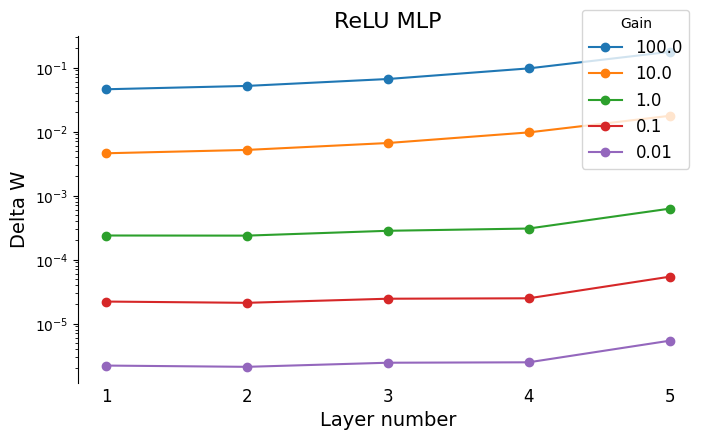

In [12]:
plot_delta_weights(delta_weights)

$||\Delta W||$ is (approximately) proportional to the gain factor, so $||\Delta W|| / ||W||$ is approximately constant as desired. It isn't exactly constant is due to the non-linearity in the softmax and cross-entropy loss in the output layer.

Next, we'll train each of these models on the MNIST dataset for 5 epochs using SGD.

In [13]:
num_epochs = 5

In [14]:
def mean(lst):
    return sum(lst) / len(lst)

def append(lst1, lst2, elem1, elem2):
    lst1.append(elem1)
    lst2.append(elem2)

In [15]:
def stats(model, X, y, logit_scaling):
    logits = model(X) / logit_scaling
    loss = F.cross_entropy(logits, y)
    accuracy = (logits.argmax(dim=1) == y).float().mean()
    return loss, accuracy

def train_step(opt, model, X, y, logit_scaling):
    loss, accuracy = stats(model, X, y, logit_scaling)
    loss.backward()
    opt.step()
    opt.zero_grad()
    return loss.item(), accuracy.item()

def val_step(model, X, y, logit_scaling):
    with torch.no_grad():
        loss, accuracy = stats(model, X, y, logit_scaling)
    return loss.item(), accuracy.item()

def val_stats(val_dl, model, logit_scaling):
    val_losses, val_accuracies = [], []
    for X, y in val_dl:
        loss, acc = val_step(model, X, y, logit_scaling)
        append(val_losses, val_accuracies, loss, acc)
    return mean(val_losses), mean(val_accuracies)

In [16]:
plot_val_per_epoch = 4

In [17]:
def train_model(gain, lr, logit_scaling):
    torch.manual_seed(0)
    train_dl, val_dl = load_data()
    model = MLP()
    apply_init(model, gain)
    opt = torch.optim.SGD(model.parameters(), lr)
    losses, accuracies = [], []
    val_losses, val_accuracies = [], []
    append(val_losses, val_accuracies, *val_stats(
        val_dl, model, logit_scaling))
    for _ in range(num_epochs):
        for i, (X, y) in enumerate(train_dl):
            loss, acc = train_step(opt, model, X, y, 
                                   logit_scaling)
            append(losses, accuracies, loss, acc)
            if (i + 1) % (len(train_dl) // plot_val_per_epoch) == 0:
                append(val_losses, val_accuracies, *val_stats(
                    val_dl, model, logit_scaling))                        
    return losses, accuracies, val_losses, val_accuracies

In [18]:
def train_models(gains, lrs, logit_scalings):
    losses, accuracies = [], []
    val_losses, val_accuracies = [], []
    for gain, lr, logit_scaling in zip(gains, lrs, logit_scalings):
        loss_curve, accuracy_curve, val_loss_curve, val_acc_curve = \
            train_model(gain, lr, logit_scaling)
        append(losses, accuracies, loss_curve, accuracy_curve)
        append(val_losses, val_accuracies, val_loss_curve, val_acc_curve)
    return losses, accuracies, val_losses, val_accuracies

In [19]:
losses, accuracies, val_losses, val_accuracies = train_models(gains, lrs, logit_scalings)

In [20]:
def plot_trainings(losses, accuracies, val_losses, 
                   val_accuracies, gains, ylims, scale_logits=False):
    fig, axs = plt.subplots(nrows=2, ncols=len(gains), squeeze=True, figsize=(8, 4))
    n_smooth = 5 # smooth accuracy curve
    accuracies_smoothed = torch.tensor(accuracies).reshape(
        len(gains), -1, n_smooth).mean(dim=-1)
    x_loss = torch.linspace(0, num_epochs, len(losses[0]))
    x_acc = torch.linspace(0, num_epochs, accuracies_smoothed.shape[1])
    x_val = torch.linspace(0, num_epochs, len(val_losses[0]))
    for i, gain in enumerate(gains):
        axs[0, i].plot(x_loss, losses[i], label='Training')
        axs[0, i].plot(x_val, val_losses[i], linestyle='--', label='Validation')
        axs[1, i].plot(x_acc, accuracies_smoothed[i], label='Training')
        axs[1, i].plot(x_val, val_accuracies[i], linestyle='--', label='Validation')
        axs[0, i].set_xlim([0, num_epochs])
        axs[1, i].set_xlim([0, num_epochs])
        axs[0, i].set_ylim([0, ylims[i]])
        axs[1, i].set_ylim([0, 1])
        axs[0, i].spines[['top', 'right']].set_visible(False)
        axs[1, i].spines[['top', 'right']].set_visible(False)
        axs[0, i].set_xticks([])
        axs[1, i].set_xticks([num_epochs/2])
        axs[1, i].set_xticklabels([f'{gain}'], fontsize=12)
        axs[1, i].set_yticks([0, 0.5, 1.0])
        axs[1, i].set_yticklabels(['0', '0.5', '1.0'])
        axs[0, i].tick_params(axis='x', which='both', length=0)
        axs[1, i].tick_params(axis='x', which='both', length=0)
        axs[0, i].tick_params(axis='y', which='both', length=0)
        axs[1, i].tick_params(axis='y', which='both', length=0)
    axs[1, 2].set_xlabel('Gain factor', fontsize=14)
    if scale_logits is False:
        axs[0, 1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axs[0, 0].set_ylabel('Loss', fontsize=14)
    axs[1, 0].set_ylabel('Accuracy', fontsize=14)
    fig.tight_layout()
    axs[0, 0].legend(frameon=False, fontsize=9, loc='upper right', bbox_to_anchor=(1.15, 1.0))

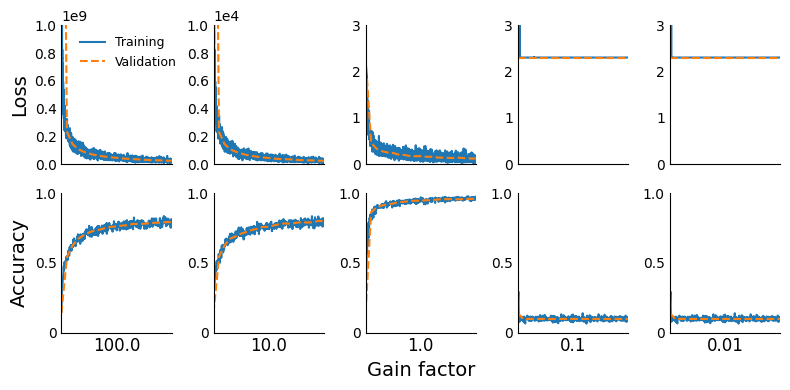

In [21]:
plot_trainings(losses, accuracies, val_losses, val_accuracies,
               gains, ylims=[1e9, 1e4, 3e0, 3e0, 3e0])
plt.savefig('exploding_activations_curves.png')
plt.show()

## Second experiment: scale output activations to same value

In this experiment, we set `logit_scalings` so that the logits (the output layer activation) are the same for each value of the gain factor. This requires rescaling the learning rate so that $\|\Delta W\|/\|W\|$ is constant for each value of the gain factor.

In [22]:
gains2 = [10.0**i for i in range(2, -3, -1)]
print(f"Initialization gain factors: {gains2}")
lrs2 = [default_lr * (10**2)**i for i in range(2, -3, -1)]
print(f"Learning rates: {lrs2}")
logit_scalings2 = [(10**num_layers)**i for i in range(2, -3, -1)]
print(f"Output activation (logit) scalings: {logit_scalings2}")

Initialization gain factors: [100.0, 10.0, 1.0, 0.1, 0.01]
Learning rates: [500.0, 5.0, 0.05, 0.0005, 5e-06]
Output activation (logit) scalings: [10000000000, 100000, 1, 1e-05, 1e-10]


Let's once again check that we chose the learning rate correctly.

In [23]:
delta_weights2 = compute_delta_weights(gains2, lrs2, logit_scalings2)

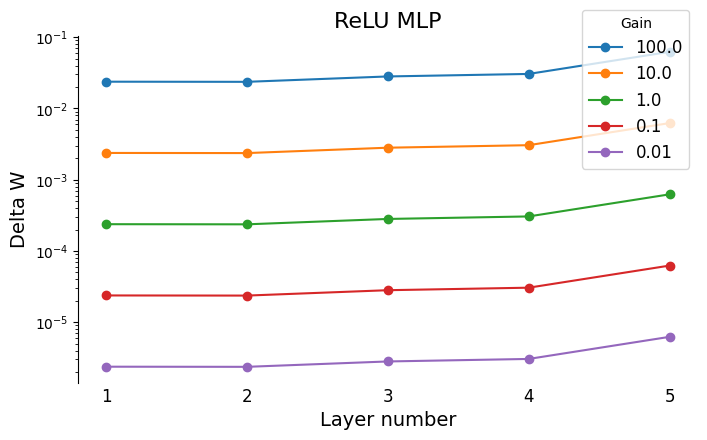

In [24]:
plot_delta_weights(delta_weights2)

Next, we again train each model using the new `logit_scalings` values

In [25]:
losses2, accuracies2, val_losses2, val_accuracies2 = train_models(gains2, lrs2, logit_scalings2)

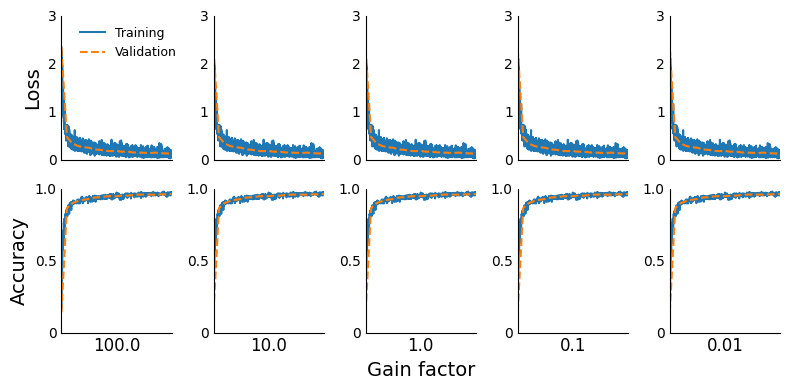

In [26]:
plot_trainings(losses2, accuracies2, val_losses2, val_accuracies2, 
               gains2, ylims=[3e0] * len(gains2), scale_logits=True)
plt.savefig('exploding_activations_curves_scale_logits.png')
plt.show()